## Table of Contents:
* [1. Plot downsampling parameter space](#first-bullet)
* [2. Plot F1 as function of condition](#second-bullet)
    * [2.1 By Tool](#second1-bullet)
    * [2.2 Global Figure](#second2-bullet)
    * [2.3 By TPR](#second3-bullet)
      - requires all *metrics.csv.gz files
    * [2.4 TF-agnostic](#second4-bullet)
    * [2.5 Peak subset](#second5-bullet)
    * [2.6 Overall Reccomendation](#second6-bullet)
* [3. Plot replicate similarity](#third-bullet)
    - requires all *metrics.csv.gz files

In [7]:
import pybedtools, os, re, pickle
import pandas as pd
import numpy as np

from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec

from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.lines as lines
from scipy.cluster import hierarchy
from matplotlib.lines import Line2D   
import itertools

In [8]:
sns.set(style='whitegrid', rc={"figure.dpi":100, 'savefig.dpi':300})  
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = ['Arial', 'sans-serif']

color_scheme_cl = {"GM12878": "#267A9E", "MCF7": "#51A885", "K562":"#F5A936", "SKNSH": "#DB7476", "HEPG2": "#986B9B"}
color_scheme_prog = {"tobias":"#008080", "hint":"#CC5500", "print": "#A4254E"}
color_scheme_st = {"cells":"#005D93", "frip":"#00BBA2", "reads":"#ffc000", "baseline":"black"}

# 1. Plot downsampling parameter space <a class="anchor" id="first-bullet"></a>

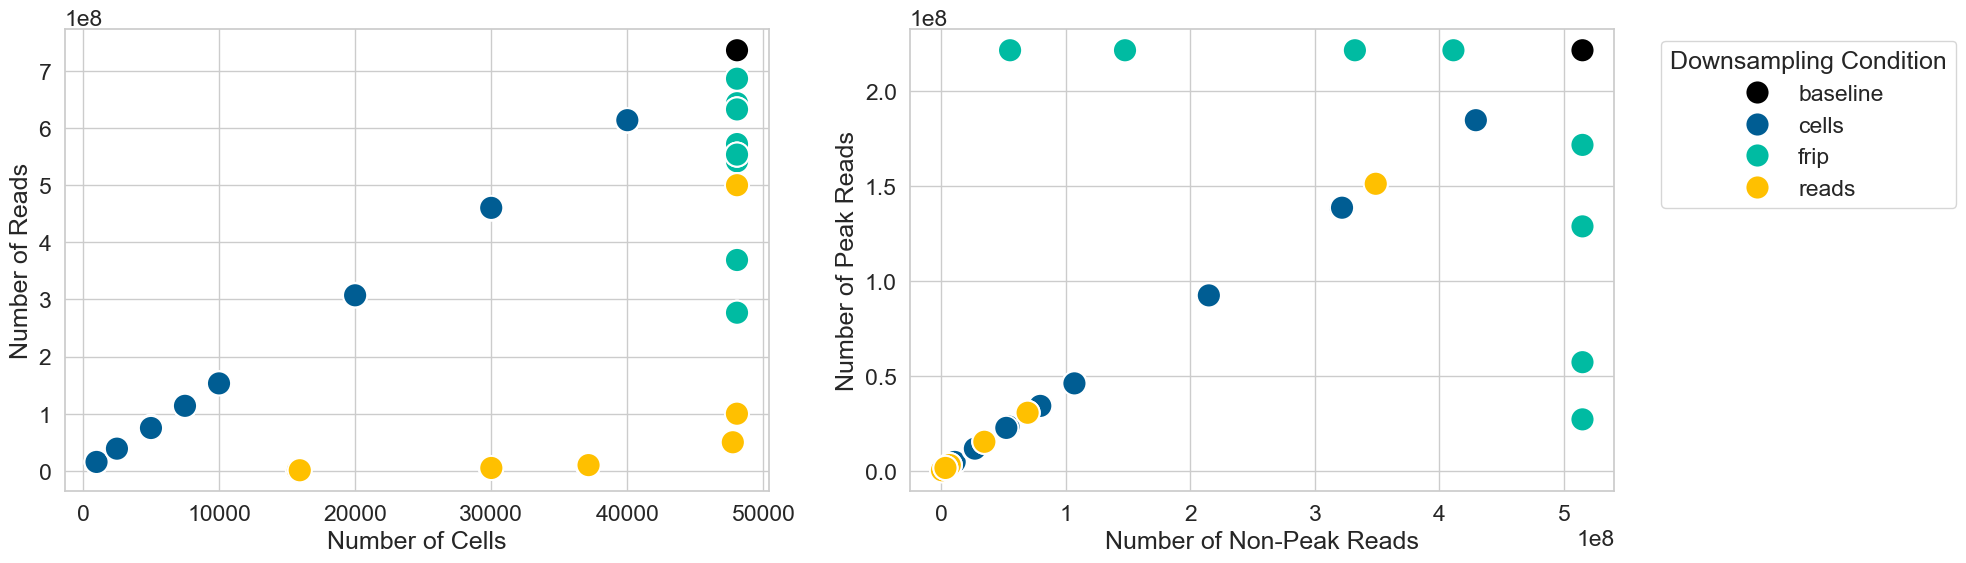

In [9]:
#get dataframe
data_dir = f"../06_dataquality/hint/metrics/no_threshold/"
cl = "K562"

df = pd.DataFrame()
tmp = pd.read_csv(f"{data_dir}/{cl}_bytf.csv.gz", sep=",", index_col=0)
cond1 = tmp["by"] == "file" 
cond3 = tmp["sampling_type"] == "baseline"
df = pd.concat([df, tmp[cond1 | cond3].copy()]) 
df = df[df.sampling_type != "peakreads"]

sns.set(font_scale=1.5, style='whitegrid')
fig = plt.figure(figsize=(20, 6))
gs = GridSpec(1, 2, figure=fig, hspace=0.4)

ax0 = fig.add_subplot(gs[0])
g = sns.scatterplot(data=df, x="Ncells", y="Nreadpairs", hue="sampling_type",  s=300, palette=color_scheme_st)
ax0.set_ylabel('Number of Reads'); ax0.set_xlabel('Number of Cells')
ax0.get_legend().remove()

ax1 = fig.add_subplot(gs[1])
g = sns.scatterplot(data=df, x="Nnonpeakpairs", y="Npeakpairs", hue="sampling_type", 
                    s=300, palette=color_scheme_st)
ax1.set_ylabel('Number of Peak Reads'); ax1.set_xlabel('Number of Non-Peak Reads')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Downsampling Condition")

plt.show()

# 2. Plot F1 as function of condition <a class="anchor" id="second-bullet"></a>

In [10]:

def baseplot(ax0, df, baseline=True, metric="f1", color="black", ls="solid", line_label=" ", pwm=False, lw=2, error_on=True, ms=6):
    sns.set(style = "whitegrid", font_scale=1.5)
    
    obj = zip(df["x"].to_list(),
              df[f"{metric}_mean"].to_list(),
              df[f"{metric}_sd"].to_list())
    myx, myy, mye = zip(*sorted(obj))
    ax0.plot(myx, myy, linestyle=ls, marker="o", linewidth=lw, markersize=ms, color=color, label=line_label)
    if error_on: ax0.errorbar(myx, myy, yerr=mye, fmt='o',linewidth=lw, color=color, linestyle=ls)

    if baseline:
        obj = zip(df[df.sampling_type == "baseline"]["x"].to_list(),
                  df[df.sampling_type == "baseline"][f"{metric}_mean"].to_list())
        myx, myy = zip(*sorted(obj))
        ax0.plot(myx, myy, linestyle=ls, marker="*", linewidth=lw, markersize=ms*2, color=color)

    ax0.set_ylim(ymin=0, ymax=1.1)
    ax0.set_ylabel(metric)
    ax0.set_xlabel("")
    
    if pwm: ax0.axhline(y=1, color='black', linestyle='dashed')
    ax0.legend(loc=2, numpoints=1, ncol=1, fancybox = True, fontsize='large')
    handles, labels = ax0.get_legend_handles_labels() 
    if pwm:
        handles.append(lines.Line2D([], [], color='black', linestyle='dashed'))
        labels.append("PWM")
    label_params = handles, labels
    ax0.get_legend().remove()

    return ax0, label_params


def load_metrics(tool, cl, st, analysis_type="tf"):
    if tool == "hint":
        data_dir = f"../06_dataquality/{tool}/metrics/no_threshold/"
    elif tool == "tobias":
        #data_dir = f"../06_dataquality/{tool}/metrics/static_threshold/"
        data_dir = f"../06_dataquality/{tool}/metrics/bound_threshold/"
    elif tool == "print":
        data_dir = f"../06_dataquality/{tool}/metrics/thresh_03/"

    df = pd.read_csv(f"{data_dir}/{cl}_by{analysis_type}.csv.gz", sep=",", index_col=0)
    if st == "cells":
        df[["x"]] = df[["Ncells"]].apply(pd.to_numeric)
    elif st == "reads":
        df[["x"]] = df[["Nreadpairs"]].apply(pd.to_numeric)
    elif st == "frip":
        df[["x"]] = df[["FRIP"]].apply(pd.to_numeric)
    elif st == "peakreads":
        df[["x"]] = df[["Npeakpairs"]].apply(pd.to_numeric)
        
    cond1 = df["by"] == "condition" 
    cond2 = df["sampling_type"] == st
    cond3 = df["sampling_type"] == "baseline"
    return df[(cond1 & cond2) | cond3].copy()


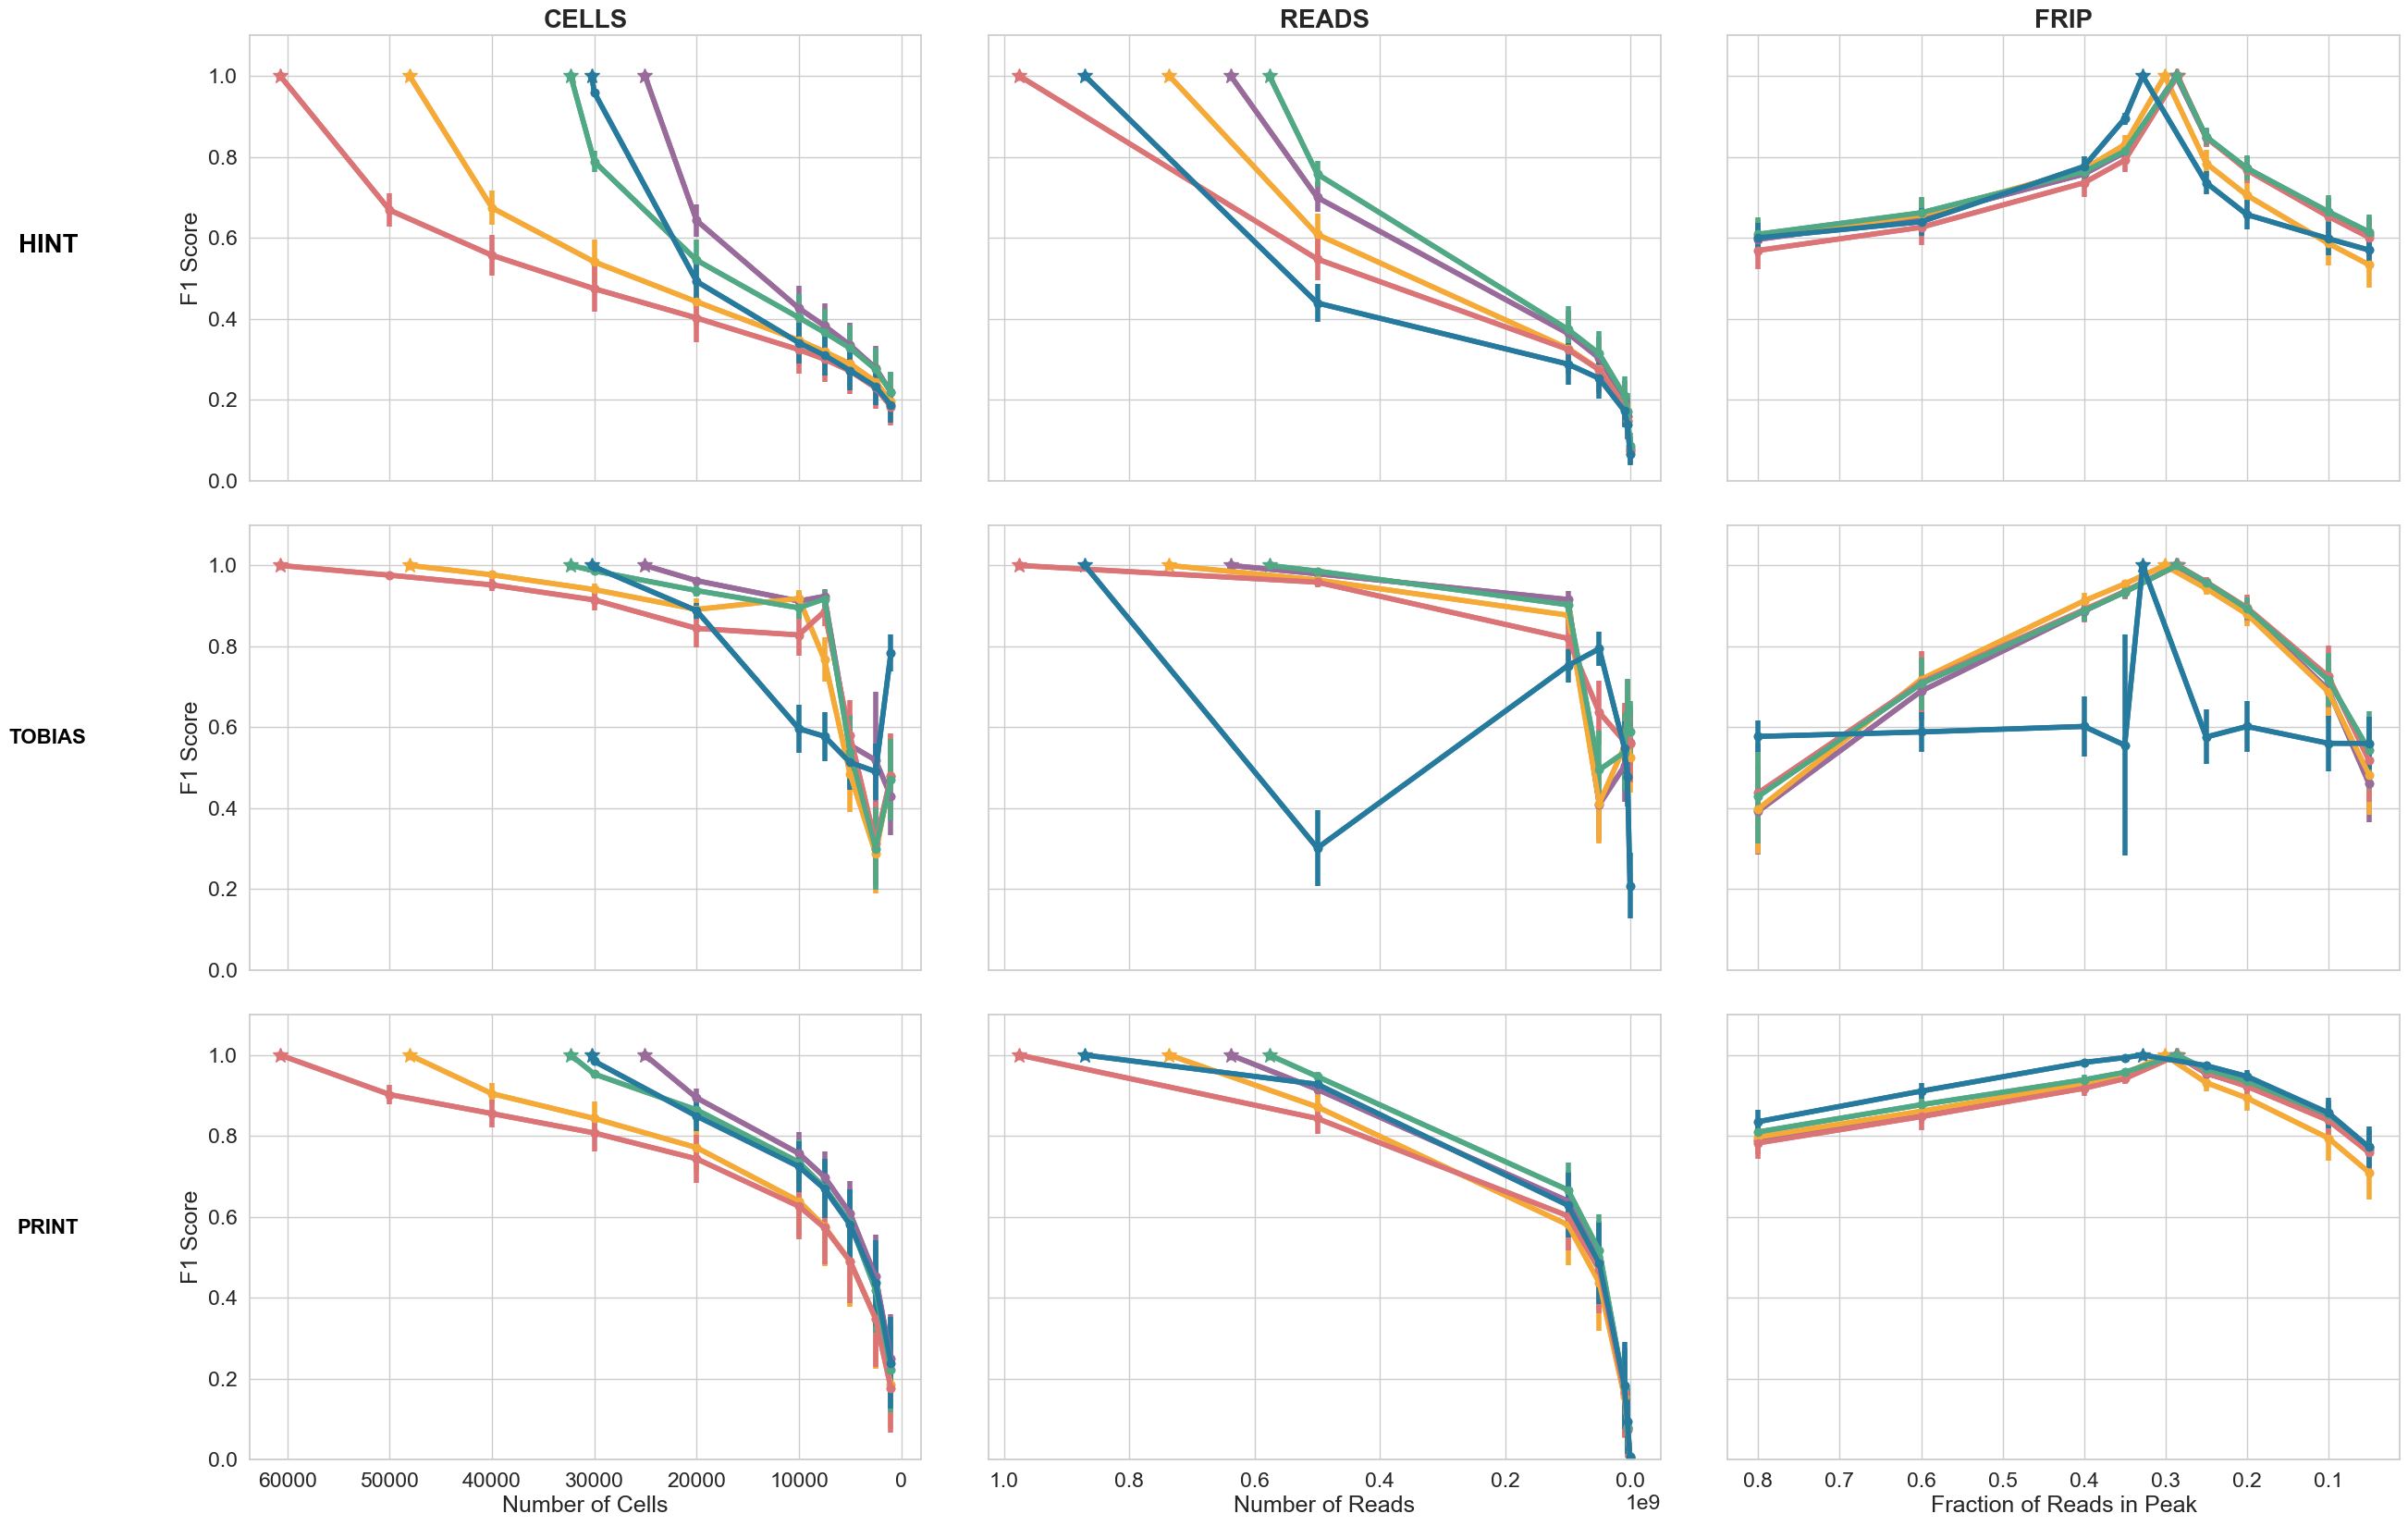

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(30,20))
axes = axes.flatten()  # Flatten to iterate easily
plt.subplots_adjust(wspace=0.1, hspace=0.1)
sns.set(font_scale=2, style='whitegrid')

pulled_legend = False
for i, (tool, st) in enumerate(list(itertools.product(["hint","tobias", "print"],
                                                      ["cells", "reads", "frip"]))):

    ax0 = axes[i]
    for cl in ["HEPG2", "K562", "SKNSH", "MCF7", "GM12878"]:
        df = load_metrics(tool, cl, st)
        ax0, tmp = baseplot(ax0, df, 
                            metric="f1", color=color_scheme_cl[cl], 
                            baseline=True, line_label=cl, lw=4)

    if not pulled_legend: 
        legend_params = tmp
        pulled_legend = True
    
    
    if i not in [0,3,6]:
        ax0.set_ylabel(""); ax0.set_yticklabels([])
    if i in [0,3,6]:
        ax0.set_ylabel("F1 Score")
    if i in range(0,6):
        ax0.set_xlabel(""); ax0.set_xticklabels([])

    # if st == "cells":
    #     ax0.set_xlim(0, 20000)
    # elif st == "reads":
    #     ax0.set_xlim(0, 3e8)

    ax0.invert_xaxis()
        
        
fs = 20
ax0 = axes[0]
ax0.set_title("CELLS", fontsize=fs, weight="bold")
ax0.text(-0.3, 0.5, "HINT", va='bottom', ha='center', rotation='horizontal', transform=ax0.transAxes, fontsize=fs, color='black', weight='bold')    

ax0 = axes[1]; ax0.set_title("READS", fontsize=fs, weight="bold")
ax0 = axes[2]; ax0.set_title("FRIP", fontsize=fs, weight="bold")

ax0 = axes[6]; ax0.set_xlabel("Number of Cells")
ax0 = axes[7]; ax0.set_xlabel("Number of Reads")
ax0 = axes[8]; ax0.set_xlabel("Fraction of Reads in Peak")

ax0 = axes[3]; ax0.text(-0.3, 0.5, "TOBIAS", va='bottom', ha='center', rotation='horizontal', transform=ax0.transAxes, fontsize=16, color='black', weight='bold')
ax0 = axes[6]; ax0.text(-0.3, 0.5, "PRINT", va='bottom', ha='center', rotation='horizontal', transform=ax0.transAxes, fontsize=16, color='black', weight='bold')

plt.show()

## 2.1 By Tool <a class="anchor" id="second1-bullet"></a>

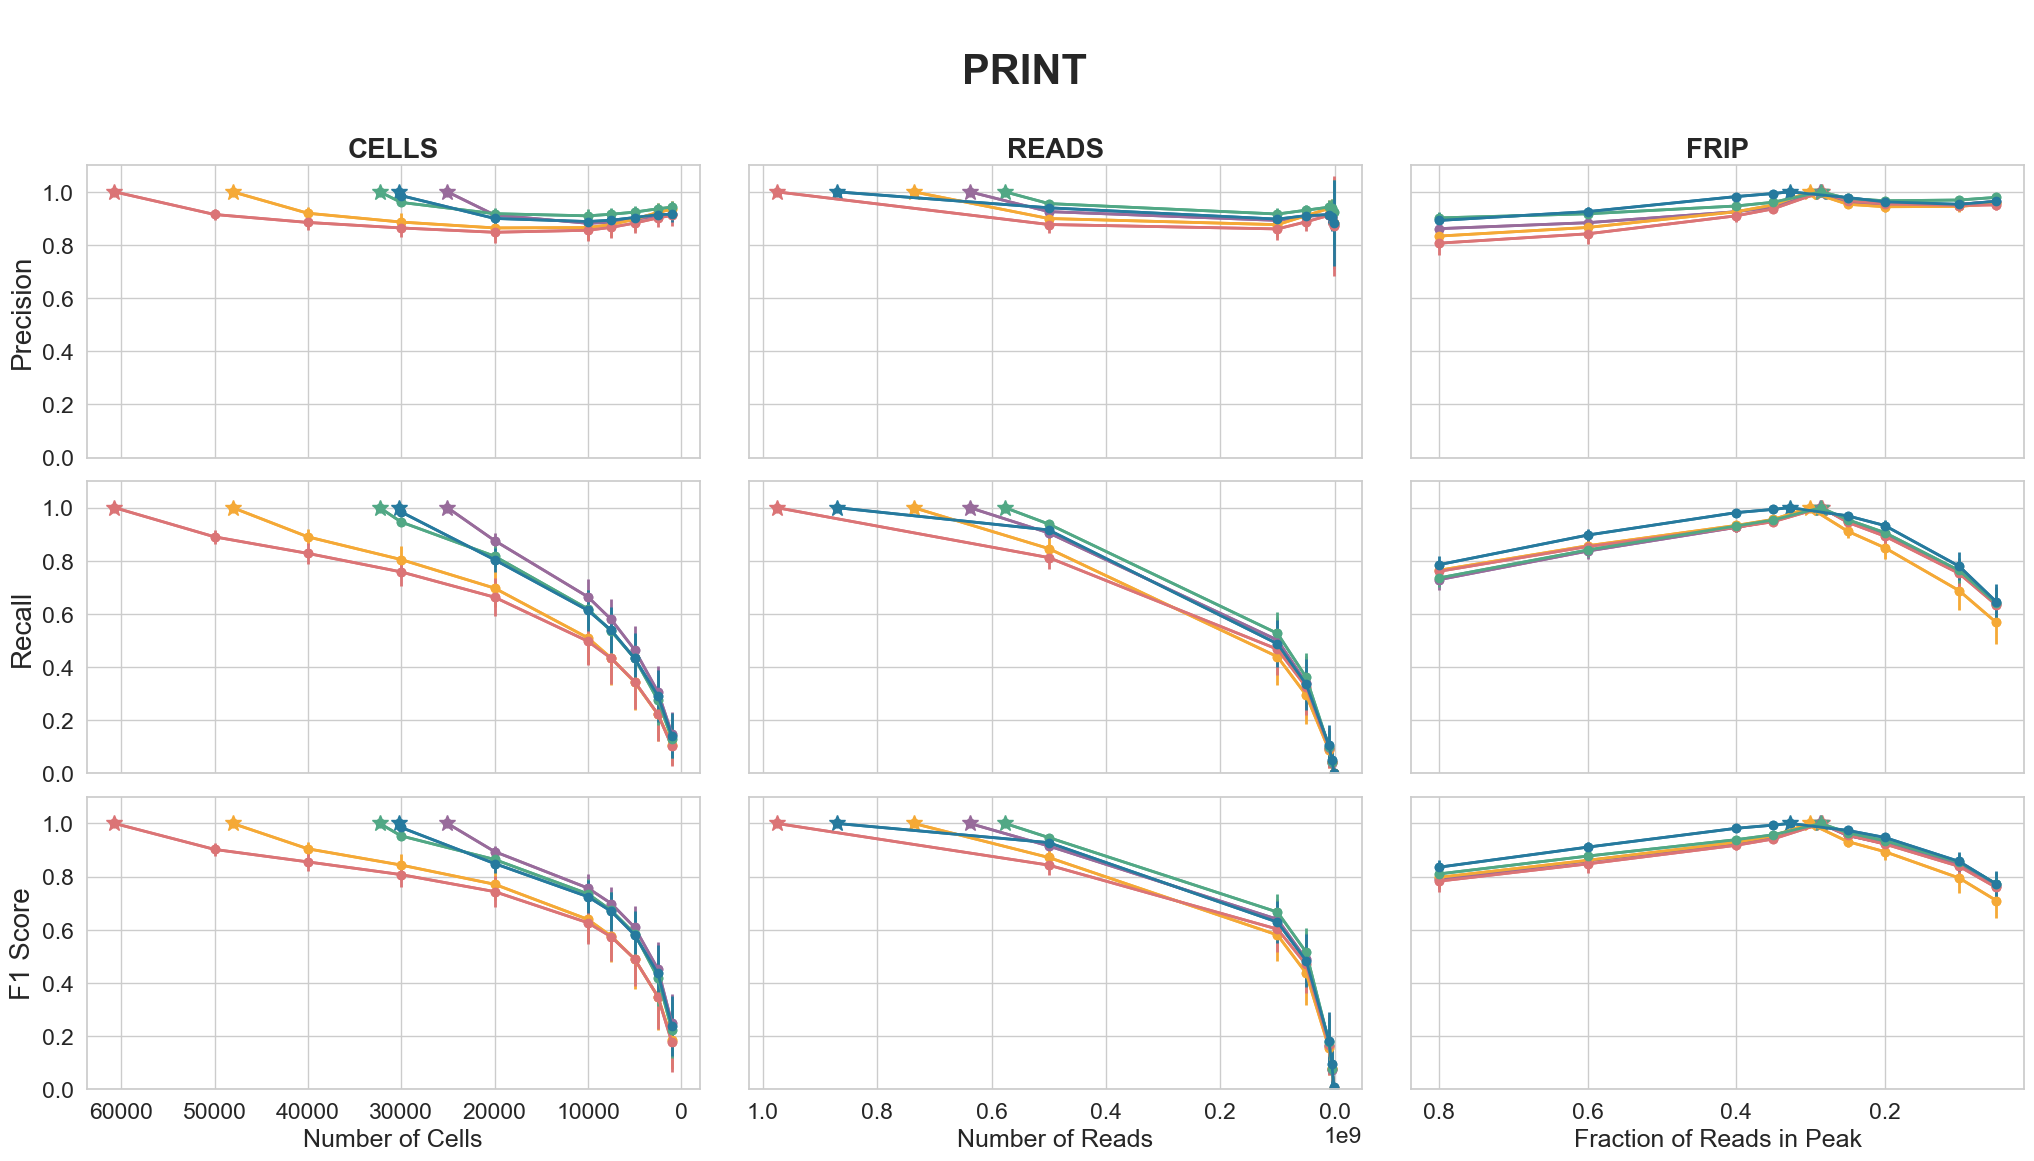

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(25,12))
axes = axes.flatten()  # Flatten to iterate easily
plt.subplots_adjust(wspace=0.08, hspace=0.08)
sns.set(font_scale=2, style='whitegrid')
fs = 20

for tool in ["print"]:
    pulled_legend = False
    for i, (mymetric, st) in enumerate(list(itertools.product(["precision", "recall", "f1"],
                                                              ["cells", "reads", "frip"]))):
        ax0 = axes[i]
    
        for cl in ["HEPG2", "K562", "SKNSH", "MCF7", "GM12878"]:
            df = load_metrics(tool, cl, st)
            ax0, tmp = baseplot(ax0, df, 
                                metric=mymetric, color=color_scheme_cl[cl], 
                                baseline=True, line_label=cl, lw=2)
    
        if not pulled_legend: 
            legend_params = tmp
            pulled_legend = True
        
        ax0.invert_xaxis()
        if i not in [0,3,6]:
            ax0.set_ylabel(""); ax0.set_yticklabels([])
        if i not in [6, 7, 8]:
            ax0.set_xlabel(""); ax0.set_xticklabels([])
    
    ax0 = axes[0]; ax0.set_title("CELLS", fontsize=fs, weight="bold")
    ax0.set_ylabel("Precision", fontsize=fs)
    ax0 = axes[1]; ax0.set_title("READS", fontsize=fs, weight="bold")
    ax0 = axes[2]; ax0.set_title("FRIP", fontsize=fs, weight="bold")
    ax0 = axes[3]; ax0.set_ylabel("Recall", fontsize=fs)
    
    ax0 = axes[6]; ax0.set_xlabel("Number of Cells"); 
    ax0.set_ylabel("F1 Score", fontsize=fs)
    ax0 = axes[7]; ax0.set_xlabel("Number of Reads")
    ax0 = axes[8]; ax0.set_xlabel("Fraction of Reads in Peak")
    fig.suptitle(f"\n{tool.upper()}", fontsize=30, weight='bold', y=1.01)
    
    plt.show()

## 2.2 Overall Figure <a class="anchor" id="second2-bullet"></a>

/tmp/ipykernel_2607908/722181391.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.0e}'.format(float(t.get_text())) for t in ax.get_yticklabels()])


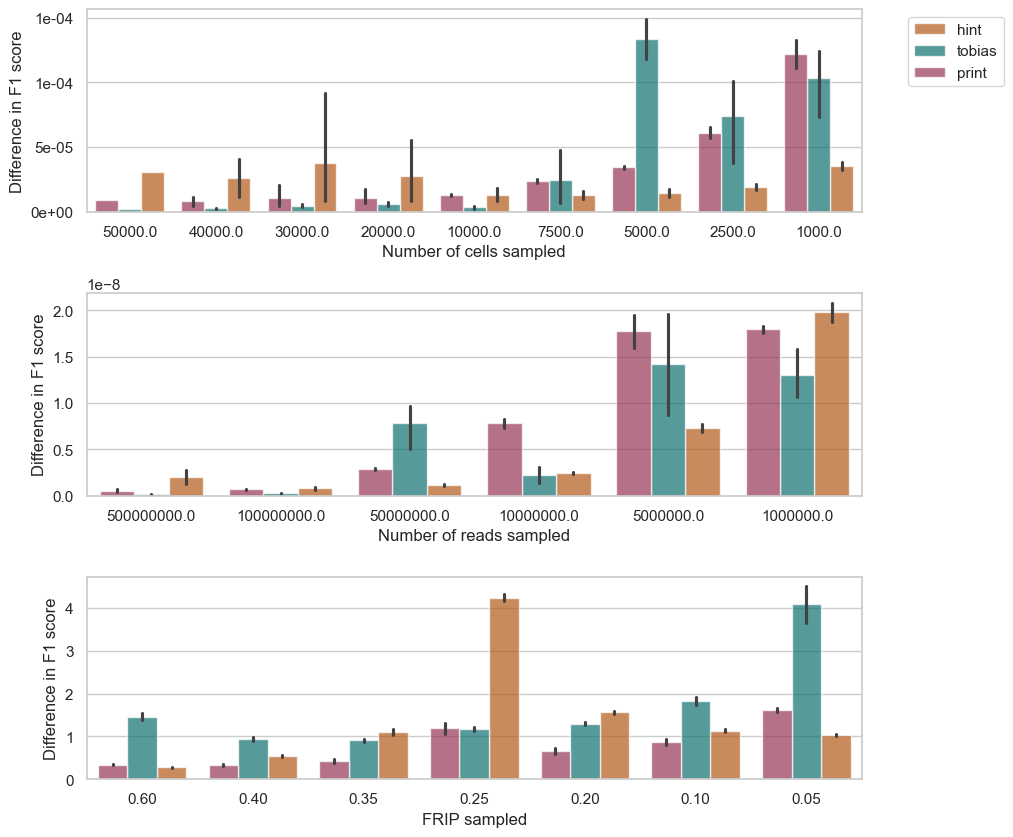

In [13]:
def quickwrapper(st):
    cells_df = pd.DataFrame()
    for tool in ["hint", "tobias","print"]:
        for cl in ["HEPG2", "K562", "SKNSH", "MCF7"]:
            df = load_metrics(tool, cl, st)
            df = df.sort_values("x", ascending=False)
            rise = df['f1_mean'].diff()
            run = df['x'].diff()
            df["f1_difference"] = rise/run
            df["tool"] = tool
            cells_df = pd.concat([cells_df, df])
    
    cells_df = cells_df[cells_df.by != "file"]
    cells_df["abs_diff"] = abs(cells_df["f1_difference"])
    return cells_df
        
import matplotlib.ticker as ticker

sns.set(font_scale=1, style='whitegrid')

fig = plt.figure(figsize=(10,10))
gs = GridSpec(3, 1, figure=fig, hspace=0.4)

ax = fig.add_subplot(gs[0])
df = quickwrapper("cells")
sns.barplot(data=df, x="x", y="abs_diff",  ax=ax, 
            hue="tool", palette=color_scheme_prog,
            legend=True, alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.invert_xaxis()
ax.set_yticklabels(['{:.0e}'.format(float(t.get_text())) for t in ax.get_yticklabels()])

ax.set_ylabel("Difference in F1 score")
ax.set_xlabel("Number of cells sampled")
#ax.set_title("Showing HINT for example")

ax = fig.add_subplot(gs[1])
df = quickwrapper("reads")
sns.barplot(data=df, x="x", y="abs_diff",  ax=ax,
            hue="tool", palette=color_scheme_prog,
            legend=False, alpha=0.7)
ax.invert_xaxis()
ax.set_ylabel("Difference in F1 score")
ax.set_xlabel("Number of reads sampled")


ax = fig.add_subplot(gs[2])
df = quickwrapper("frip")
df.dropna(subset=['abs_diff'], inplace=True)
sns.barplot(data=df, x="x", y="abs_diff",  ax=ax,
            hue="tool", palette=color_scheme_prog,
            legend=False, alpha=0.7)

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(['{:.2f}'.format(float(t.get_text())) for t in ax.get_xticklabels()])

ax.invert_xaxis()
ax.set_ylabel("Difference in F1 score")
ax.set_xlabel("FRIP sampled")

plt.show()

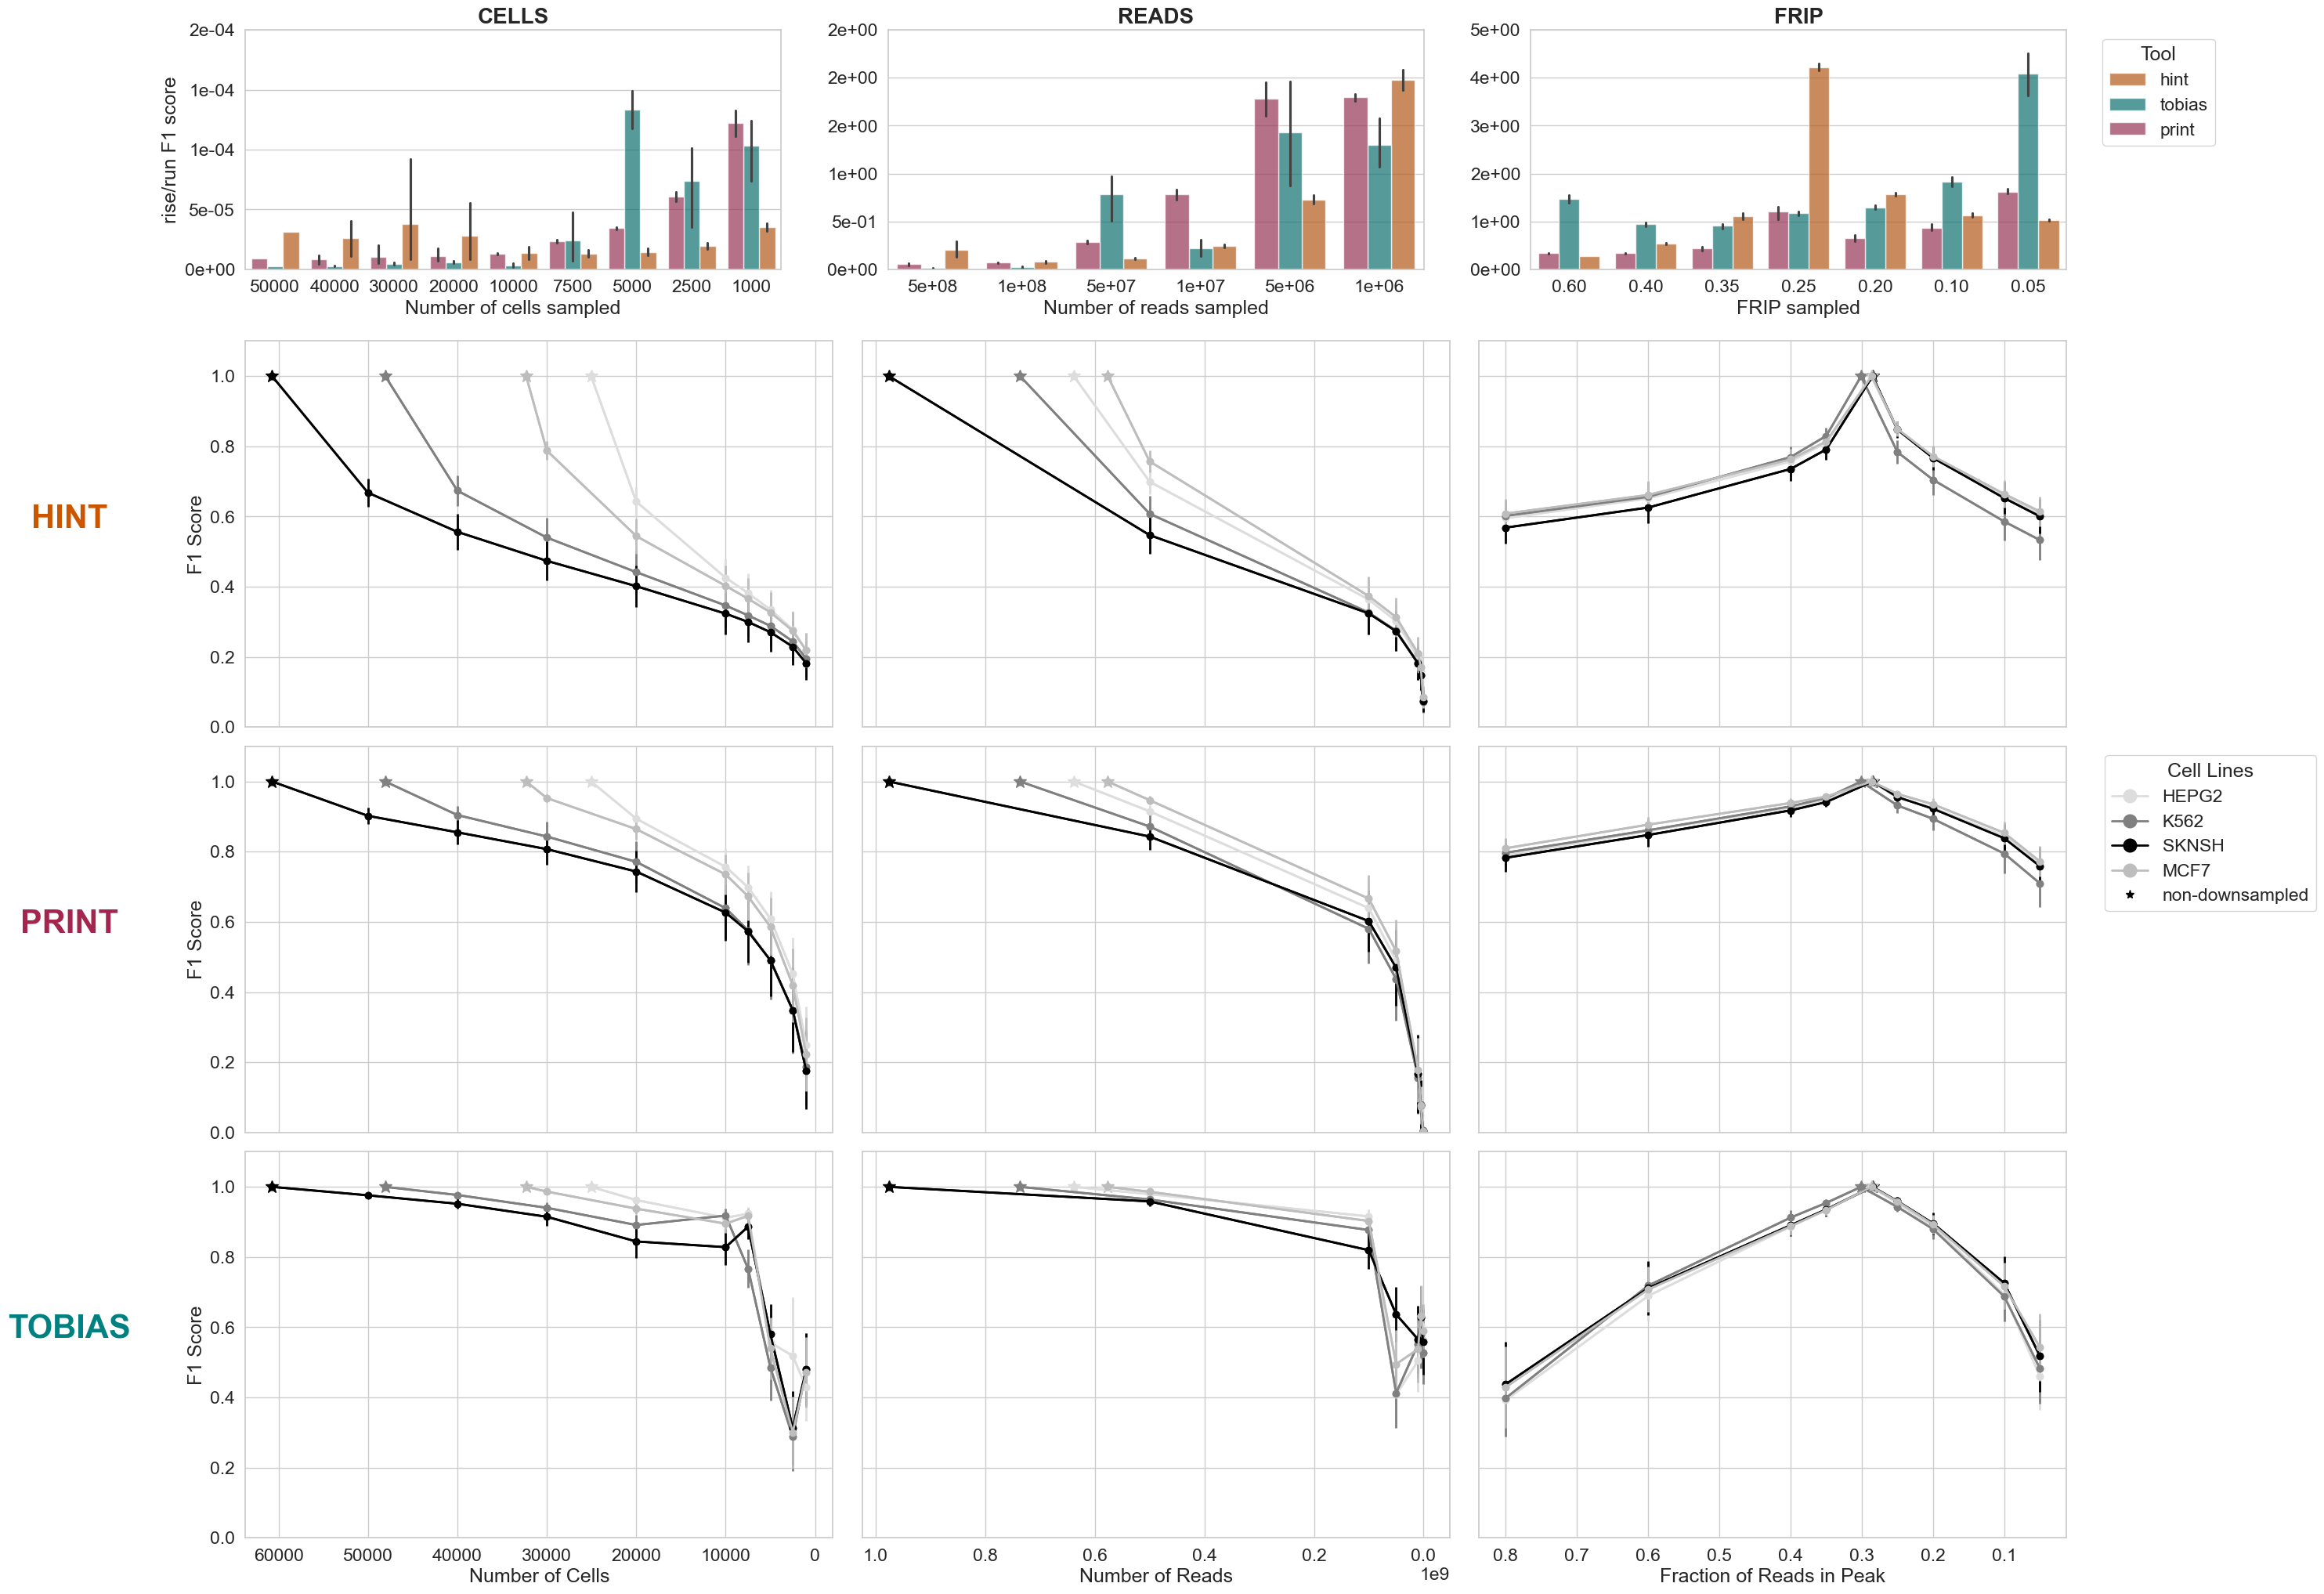

In [14]:
fig = plt.figure(figsize=(30,25))
outer = GridSpec(2,1, figure=fig, wspace = 0.5, hspace = 0.1, height_ratios=[2,10])
gs0 = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec = outer[0], wspace = 0.2)
gs1 = gridspec.GridSpecFromSubplotSpec(3, 3, subplot_spec = outer[1], wspace = 0.05, hspace = 0.05) #, width_ratios=[2,10])

sns.set(font_scale=1.5, style='whitegrid')
fs = 20   

ax = fig.add_subplot(gs0[0]) 
df = quickwrapper("cells")
sns.barplot(data=df, x="x", y="abs_diff",  ax=ax, hue="tool", palette=color_scheme_prog, legend=False, alpha=0.7)
ax.invert_xaxis()
ax.set_xticks(ax.get_xticks()); ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(['{:.0e}'.format(float(t.get_text())) for t in ax.get_yticklabels()])
ax.set_xticklabels(['{:.0f}'.format(float(t.get_text())) for t in ax.get_xticklabels()])
ax.set_xlabel("Number of cells sampled")
ax.set_ylabel("rise/run F1 score")
ax.set_title("CELLS", fontsize=fs, weight="bold")


ax = fig.add_subplot(gs0[1]) 
df = quickwrapper("reads")
sns.barplot(data=df, x="x", y="abs_diff",  ax=ax, hue="tool", palette=color_scheme_prog, legend=False, alpha=0.7)
ax.invert_xaxis()
ax.set_xticks(ax.get_xticks()); ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(['{:.0e}'.format(float(t.get_text())) for t in ax.get_yticklabels()])
ax.set_xticklabels(['{:.0e}'.format(float(t.get_text())) for t in ax.get_xticklabels()])
ax.set_xlabel("Number of reads sampled")
ax.set_ylabel("")
ax.set_title("READS", fontsize=fs, weight="bold")


ax = fig.add_subplot(gs0[2]) 
df = quickwrapper("frip")
df.dropna(subset=['abs_diff'], inplace=True)
sns.barplot(data=df, x="x", y="abs_diff",  ax=ax, hue="tool", palette=color_scheme_prog, legend=True, alpha=0.7)
ax.invert_xaxis()
ax.set_xticks(ax.get_xticks()); ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(['{:.0e}'.format(float(t.get_text())) for t in ax.get_yticklabels()])
ax.set_xticklabels(['{:.2f}'.format(float(t.get_text())) for t in ax.get_xticklabels()])
ax.set_ylabel("")
ax.set_xlabel("FRIP sampled")
ax.set_title("FRIP", fontsize=fs, weight="bold")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Tool")


axes = [fig.add_subplot(gs1[i, j]) for i in range(3) for j in range(3)]
axes = np.array(axes).flatten()

pulled_legend = False
color_scheme_cl2 = {"SKNSH": "black", "K562":"#808080", "MCF7":"#BDBDBD", "HEPG2":"#DDDDDD"}
for i, (tool, st) in enumerate(list(itertools.product(["hint", "print", "tobias"],
                                                      ["cells", "reads", "frip"]))):

    ax0 = axes[i]
    for cl in ["HEPG2", "K562", "SKNSH", "MCF7"]:
        df = load_metrics(tool, cl, st)
        ax0, tmp = baseplot(ax0, df, 
                            metric="f1", color=color_scheme_cl2[cl], 
                            baseline=True, line_label=cl)
        
    if i == 5:
        handles, labels = tmp
        star_legend = Line2D([0], [0], color='black', marker='*', linestyle='None', markersize=4)
        handles.append(star_legend)
        labels.append('non-downsampled')
        ax0.legend(handles=handles, labels=labels, title="Cell Lines",markerscale=2,
                   bbox_to_anchor=(1.05, 1), loc='upper left')

    ax0.invert_xaxis()
    if i not in [0,3,6]:
        ax0.set_ylabel(""); ax0.set_yticklabels([])
    if i in [0,3,6]:
        ax0.set_ylabel("F1 Score")
    if i in range(0,6):
        ax0.set_xlabel(""); ax0.set_xticklabels([])
        
           
fs = 30
ax0 = axes[0]; ax0.text(-0.3, 0.5, "HINT", va='bottom', ha='center', rotation='horizontal', transform=ax0.transAxes, fontsize=fs, weight='bold', color=color_scheme_prog["hint"])    
ax0 = axes[6]; ax0.text(-0.3, 0.5, "TOBIAS", va='bottom', ha='center', rotation='horizontal', transform=ax0.transAxes, fontsize=fs, weight='bold', color=color_scheme_prog["tobias"])    
ax0 = axes[3]; ax0.text(-0.3, 0.5, "PRINT", va='bottom', ha='center', rotation='horizontal', transform=ax0.transAxes, fontsize=fs, weight='bold', color=color_scheme_prog["print"])    
ax0 = axes[6]; ax0.set_xlabel("Number of Cells")
ax0 = axes[7]; ax0.set_xlabel("Number of Reads")
ax0 = axes[8]; ax0.set_xlabel("Fraction of Reads in Peak")

plt.show()

## 2.3 By TPR <a class="anchor" id="second3-bullet"></a>

In [18]:
def AddSamplingStats(df, row_type="sample"):
    
    def transform_to_dict(file_list):
        result = {}
        for item in file_list:
            if "_" not in item:  prefix = item
            else:                prefix = "_".join(item.split('_')[:-1])

            if prefix not in result:
                result[prefix] = []
            result[prefix].append(item)
        return result
    
    all_metrics = pd.read_csv("../04_downsampling/sampling_stats.csv", sep=",", index_col=0)
    all_metrics.index = [re.sub("_dict" , "", x) for x in all_metrics.index]
    
    if row_type=="sample":
        df_INFO = df.merge(all_metrics, right_index=True, left_index=True, how='left')
    
    elif row_type=="group":
        grouping_dict = transform_to_dict(all_metrics.index)
        rows = []
        
        new_df = pd.DataFrame() 
        for g in grouping_dict.keys():
            subf = grouping_dict[g]
            group_df = all_metrics.loc[subf]
            group_df = group_df.drop(columns=["seed"])
            str_columns = ["cell_line", "sampling_type", "value"]
            str_series  = group_df[str_columns].iloc[0]
            mean_series = group_df.drop(columns=str_columns).mean(axis=0)

            combined_series = pd.concat([str_series, mean_series])
            combined_series["group"] = g
            rows.append(combined_series)
            
        new_df = pd.DataFrame(rows)
        new_df.index = new_df.group
        new_df.drop(columns=["group"], inplace=True)
        df_INFO = df.merge(new_df, right_index=True, left_index=True, how='left')
    
    return(df_INFO)



def _getTPR(tool, cl, percent=False):
    #get all metric files for this cell line. 

    if tool == "hint":
        data_dir = f"../../06_dataquality/{tool}/metrics/no_threshold/"
    elif tool == "tobias":
        data_dir = f"../../06_dataquality/{tool}/metrics/bound_threshold/"
    elif tool == "print":
        data_dir = f"../../06_dataquality/{tool}/metrics/thresh_03/"

    analysis_type = "tf"
    files = [x for x in os.listdir(data_dir) if x.endswith("_metrics.csv") and cl in x]
    files.remove(f"{cl}_metrics.csv")
    
    #if we want this as a percentage, we need the baseline number of TFBS in the file. 
    if percent:
        df = pd.read_csv(f"{data_dir}/{cl}_metrics.csv", index_col=0)
        df = df.loc[df["type"] == analysis_type]
        df = df.sort_index(ascending=True)
        denom = df.TP.values
        
    p_dict = {}
    for f in files:
        df = pd.read_csv(f"{data_dir}/{f}", index_col=0)
        df = df.loc[df["type"] == analysis_type]
        df = df.sort_index(ascending=True)
        if percent: p_dict[re.sub("_metrics.csv", '', f) ] = (df.TP.values/denom)*100
        else: p_dict[re.sub("_metrics.csv", '', f) ] = df.TP.values

    p_dict["TF"] = df.index
    zscore_df = pd.DataFrame.from_dict(p_dict)
    zscore_df.index = zscore_df.TF

    zscore_df_long = pd.melt(zscore_df, id_vars=['TF'], var_name='file', value_name='value')
    zscore_df_long[["cell_line", "tmp", "seed"]] = zscore_df_long.file.str.split('_', expand=True)
    zscore_df_long["group"] = [s[:1] for s in zscore_df_long["tmp"]]
    zscore_df_long["condition"] = [s[1:] for s in zscore_df_long["tmp"]]
    
    zscore_df_long["name"] = zscore_df_long["cell_line"] + "_" +zscore_df_long["group"] + zscore_df_long["condition"]
    zscore_df_long = zscore_df_long[zscore_df_long.group !="p"]
    return(zscore_df_long)


def runall(prog):
    df = pd.concat([_getTPR(prog, "HEPG2", percent=True),
                    _getTPR(prog, "K562", percent=True),
                    _getTPR(prog, "SKNSH", percent=True),
                    _getTPR(prog, "MCF7", percent=True),
                     _getTPR(prog, "GM12878", percent=True)
                         ])
    df_mean = df.groupby(["name"])["value"].agg(['mean', 'std']).reset_index()
    df_mean = pd.concat([df_mean, 
                        pd.DataFrame([("HEPG2", 100, 0), 
                                      ("K562", 100, 0),
                                      ("SKNSH", 100, 0),
                                      ("MCF7", 100, 0),
                                      ("GM12878", 100, 0)], 
                                     columns=['name', 'mean', 'std'])])
    df_mean.index = df_mean.name
    df_mean.drop("name", axis=1, inplace=True)
    df_mean.columns = ["TP_mean", "TP_sd"]
    df_mean = AddSamplingStats(df_mean, row_type="group")
    return df_mean

tpr_dict = {"hint":runall("hint"),
            "tobias":runall("tobias"),
            "print":runall("print")}
print("done")

done


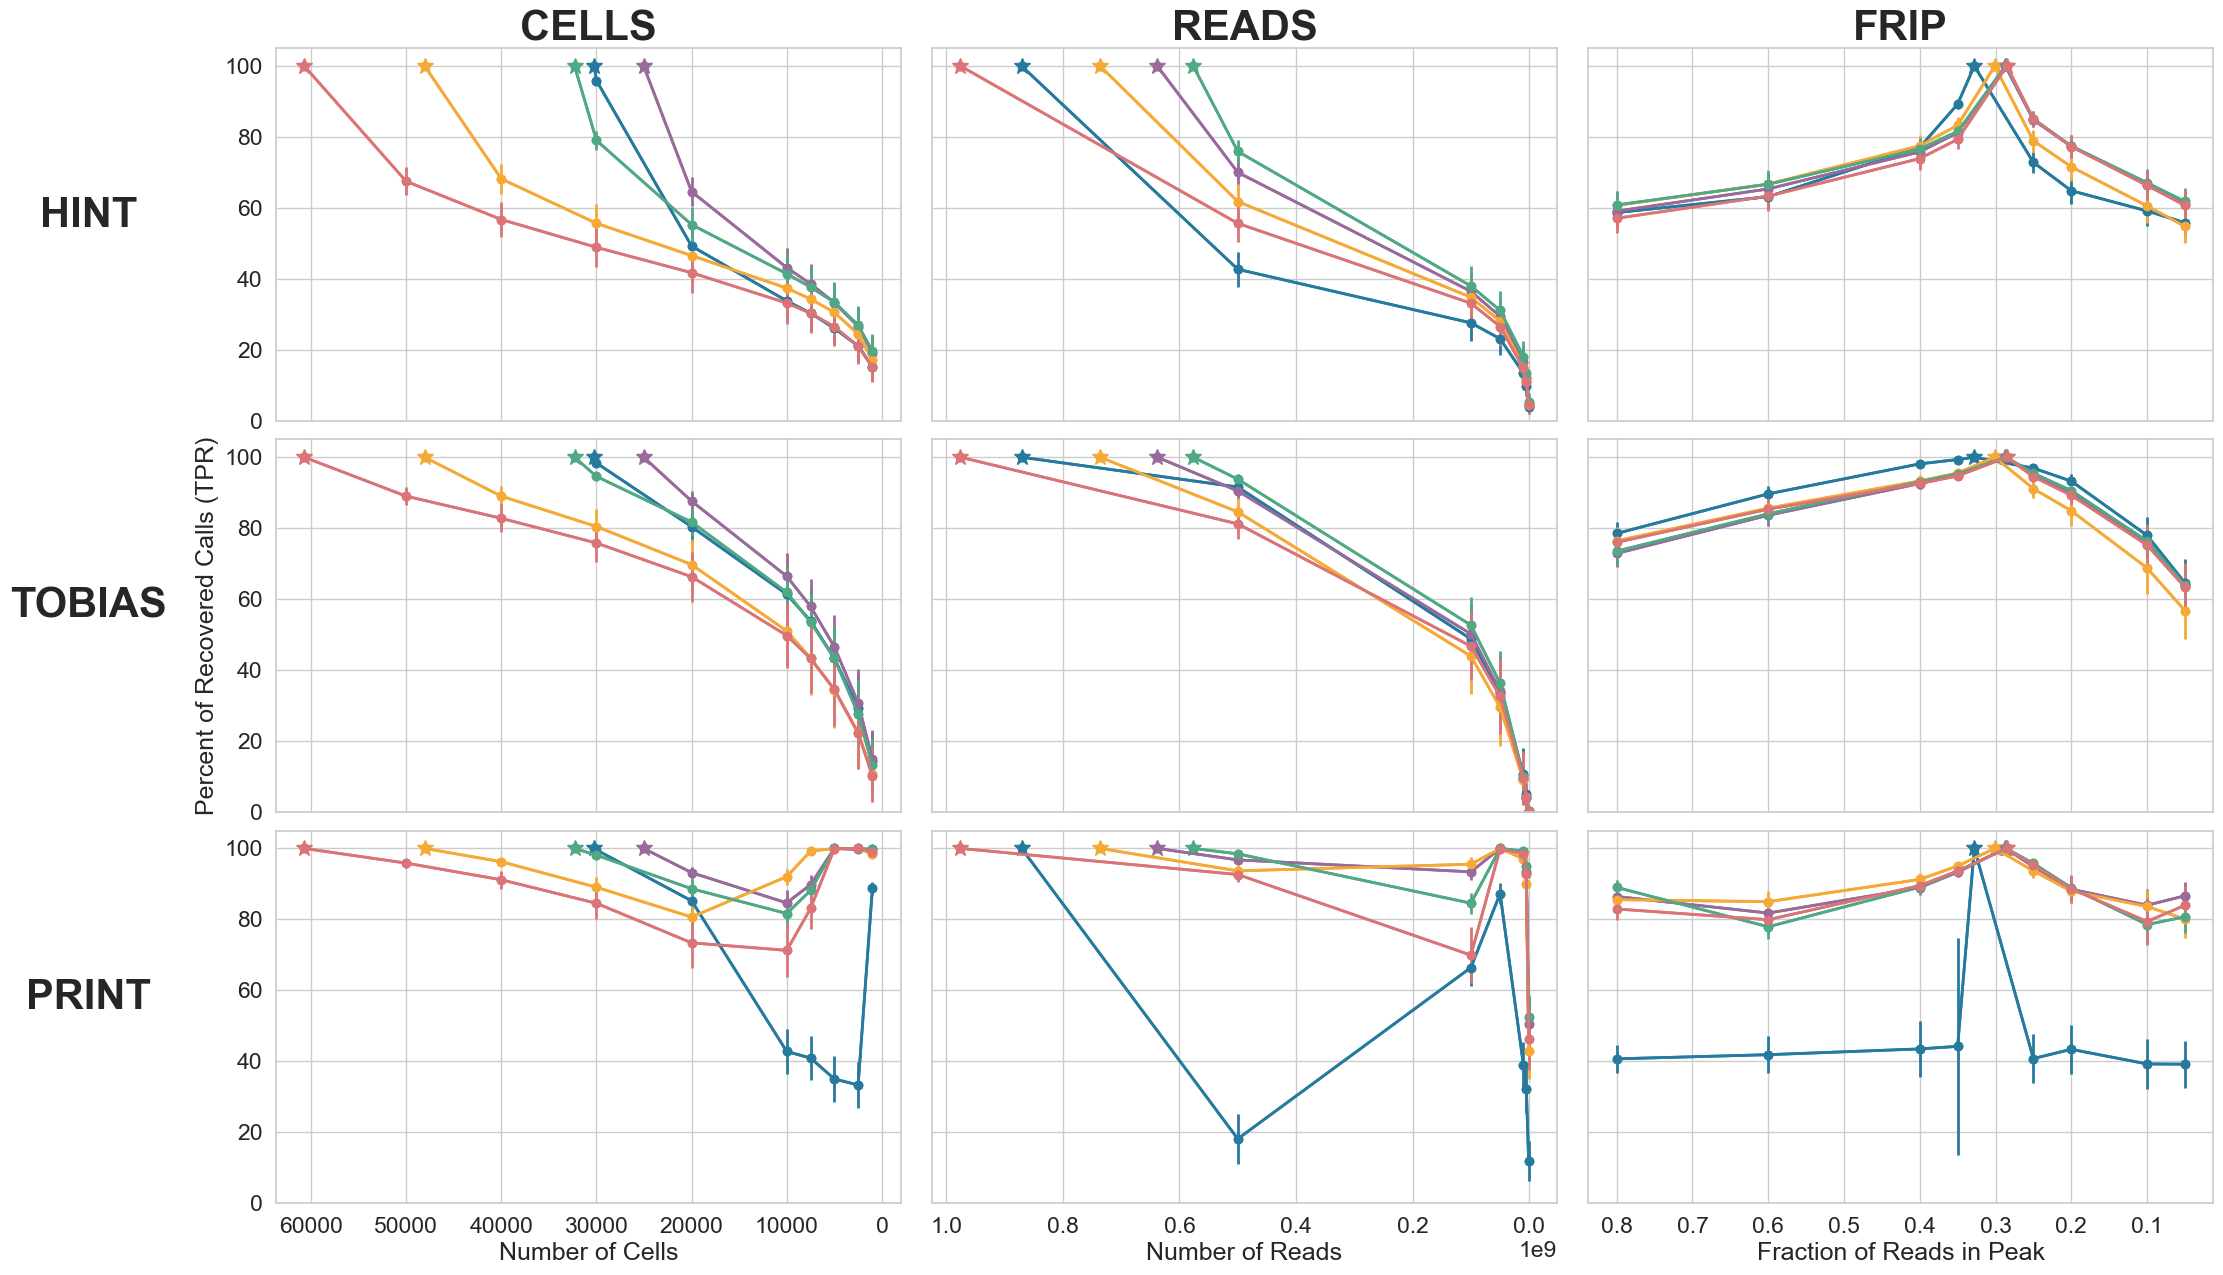

In [19]:
def quick_process(df, st):
    if st == "cells":
        df[["x"]] = df[["Ncells"]].apply(pd.to_numeric)
    elif st == "reads":
        df[["x"]] = df[["Nreadpairs"]].apply(pd.to_numeric)
    elif st == "frip":
        df[["x"]] = df[["FRIP"]].apply(pd.to_numeric)
    elif st == "peakreads":
        df[["x"]] = df[["Npeakpairs"]].apply(pd.to_numeric)
    return df


fig, axes = plt.subplots(3, 3, figsize=(25, 15))
axes = axes.flatten()  # Flatten to iterate easily
plt.subplots_adjust(wspace=0.05, hspace=0.05)
sns.set(font_scale=1.5, style='whitegrid')

pulled_legend = False
for i, (tool, st) in enumerate(list(itertools.product(["hint","print", "tobias"],
                                                      ["cells", "reads", "frip"]))):
                                        
    ax0 = axes[i]
 
    df = tpr_dict[tool]
    df = df[df.sampling_type.isin([st, "baseline"])].copy()
    df = quick_process(df, st)
    for cl in np.unique(df.cell_line):
        tmp = df[df.cell_line == cl]
        ax0, tmp = baseplot(ax0, tmp, 
                            metric="TP", color=color_scheme_cl[cl], 
                            baseline=True, line_label=cl)
        ax0.set_ylim(ymin=0, ymax=105)
    if not pulled_legend: 
        legend_params = tmp
        pulled_legend = True
    
    ax0.invert_xaxis()
    if i not in [0,3,6]:
        ax0.set_ylabel(""); ax0.set_yticklabels([])
    if i not in [6, 7, 8]:
        ax0.set_xlabel(""); ax0.set_xticklabels([])
    if i in [0,3,6]:
        ax0.set_ylabel("")
        #ax0.set_ylabel("Percent of Recovered Calls (TPR)")

ax0 = axes[0]; ax0.set_title("CELLS", fontsize=fs, weight="bold")
ax0 = axes[1]; ax0.set_title("READS", fontsize=fs, weight="bold")
ax0 = axes[2]; ax0.set_title("FRIP", fontsize=fs, weight="bold")
ax0 = axes[6]; ax0.set_xlabel("Number of Cells") 
ax0 = axes[7]; ax0.set_xlabel("Number of Reads")
ax0 = axes[8]; ax0.set_xlabel("Fraction of Reads in Peak")
ax0 = axes[3]; ax0.set_ylabel("Percent of Recovered Calls (TPR)")
ax0 = axes[0]; ax0.text(-0.3, 0.5, "HINT", va='bottom', ha='center', rotation='horizontal', transform=ax0.transAxes, fontsize=fs, weight='bold') #, color=color_scheme_prog["hint"])    
ax0 = axes[3]; ax0.text(-0.3, 0.5, "TOBIAS", va='bottom', ha='center', rotation='horizontal', transform=ax0.transAxes, fontsize=fs, weight='bold')#, color=color_scheme_prog["tobias"])    
ax0 = axes[6]; ax0.text(-0.3, 0.5, "PRINT", va='bottom', ha='center', rotation='horizontal', transform=ax0.transAxes, fontsize=fs, weight='bold')#, color=color_scheme_prog["print"])    
plt.show()


## 2.4 TF-agnostic <a class="anchor" id="second4-bullet"></a>

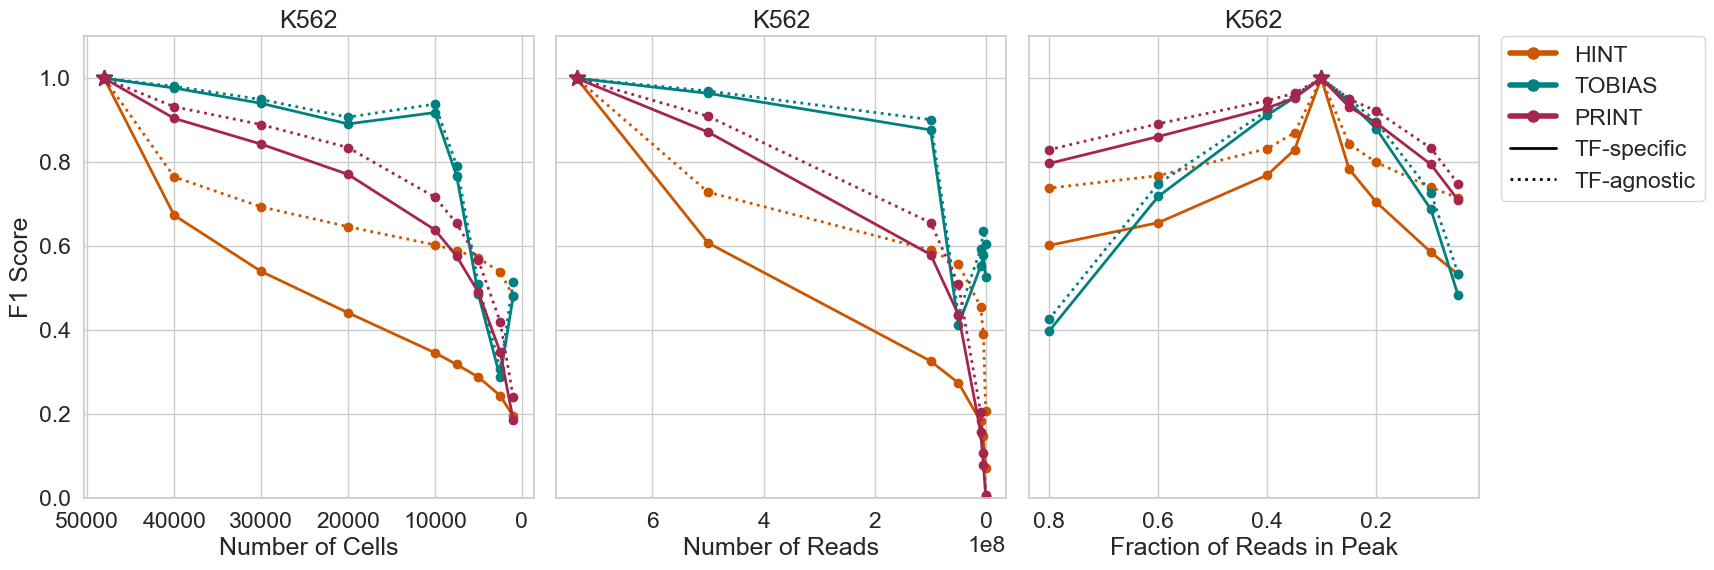

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes = axes.flatten()  # Flatten to iterate easily
plt.subplots_adjust(wspace=0.05, hspace=0.05)
sns.set(style='whitegrid')

cl="K562"
pulled_legend = False
for i, st in enumerate(["cells", "reads", "frip"]):
                                        
    ax0 = axes[i]
    for tool in ["hint","tobias", "print"]:
        tmp = load_metrics(tool, cl, st, "tf")
        ax0, _ = baseplot(ax0, tmp, metric="f1", color=color_scheme_prog[tool], 
                          baseline=True, line_label="bytf", ls="solid", error_on=False)
        tmp = load_metrics(tool, cl, st, "peak")
        ax0, tmp = baseplot(ax0, tmp, metric="f1", color=color_scheme_prog[tool], 
                          baseline=True, line_label="bypeak", ls="dotted", error_on=False)
        
    ax0.invert_xaxis()


ax0 = axes[0]; ax0.set_xlabel("Number of Cells"); ax0.set_ylabel("F1 Score"); ax0.set_title(cl) 
ax0 = axes[1]; ax0.set_xlabel("Number of Reads"); ax0.set_title(cl) 
ax0.set_ylabel(""); ax0.set_yticklabels([])
ax0 = axes[2]; ax0.set_xlabel("Fraction of Reads in Peak"); ax0.set_title(cl) 
ax0.set_ylabel(""); ax0.set_yticklabels([])



# Define custom labels and line styles
labels = ["HINT", "TOBIAS", "PRINT", "TF-specific", "TF-agnostic"]
styles = ["solid","solid","solid","solid", "dotted"]
colors = [color_scheme_prog["hint"], color_scheme_prog["tobias"],color_scheme_prog["print"], "black", "black"]
markers = ["o", "o", "o", "", ""]
widths = [4,4,4,2,2]
handles = [Line2D([], [], color=color, linestyle=style, label=label, marker=marker, linewidth=width, markersize=8) 
           for color, style, label, marker, width in zip(colors, styles, labels, markers, widths)]

plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.show()

## 2.5 Peak Subset <a class="anchor" id="second5-bullet"></a>

In [21]:
def _peak_load_metrics(tool, cl, st, analysis_type="tf"):
    if tool == "hint":
        data_dir = f"../06_dataquality/{tool}/metrics/no_threshold_peak100/"
    elif tool == "tobias":
        data_dir = f"../06_dataquality/{tool}/metrics/bound_threshold_peak100/"
    elif tool == "print":
        data_dir = f"../06_dataquality/{tool}/metrics/thresh_03_peak100/"

    df = pd.read_csv(f"{data_dir}/{cl}_by{analysis_type}.csv.gz", sep=",", index_col=0)
    if st == "cells":
        df[["x"]] = df[["Ncells"]].apply(pd.to_numeric)
    elif st == "reads":
        df[["x"]] = df[["Nreadpairs"]].apply(pd.to_numeric)
    elif st == "frip":
        df[["x"]] = df[["FRIP"]].apply(pd.to_numeric)
    elif st == "peakreads":
        df[["x"]] = df[["Npeakpairs"]].apply(pd.to_numeric)
        
    cond1 = df["by"] == "condition" 
    cond2 = df["sampling_type"] == st
    cond3 = df["sampling_type"] == "baseline"
    return df[(cond1 & cond2) | cond3].copy()

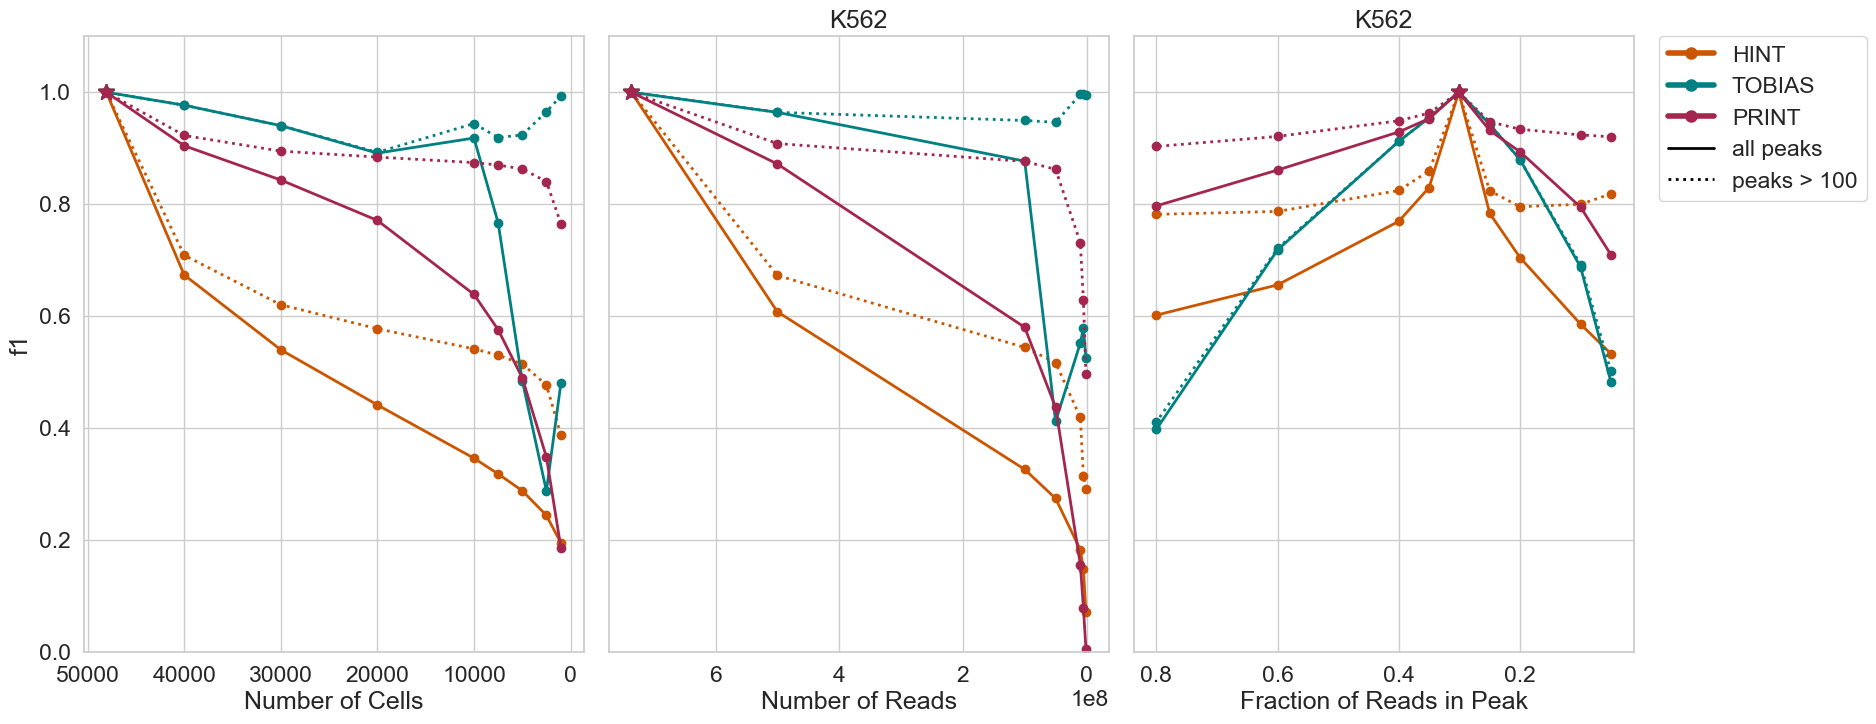

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20,8))
axes = axes.flatten()  # Flatten to iterate easily
plt.subplots_adjust(wspace=0.05, hspace=0.05)
sns.set(style='whitegrid')

y = "f1"
cl="K562"
pulled_legend = False
for i, st in enumerate(["cells", "reads", "frip"]):                           
    ax0 = axes[i]
    for tool in ["hint","tobias", "print"]:
        tmp = load_metrics(tool, cl, st, "tf")
        ax0, _ = baseplot(ax0, tmp, metric=y, color=color_scheme_prog[tool], 
                          baseline=True, line_label="bytf", ls="solid", error_on=False)

        tmp = _peak_load_metrics(tool, cl, st, "tf")
        ax0, tmp = baseplot(ax0, tmp, metric=y, color=color_scheme_prog[tool], 
                          baseline=True, line_label="bypeak", ls="dotted", error_on=False)

    ax0.invert_xaxis()

ax0 = axes[0]; ax0.set_xlabel("Number of Cells"); #ax0.set_ylabel("F1 Score"); ax0.set_title(cl) 
ax0 = axes[1]; ax0.set_xlabel("Number of Reads"); ax0.set_title(cl) 
ax0.set_ylabel(""); ax0.set_yticklabels([])
ax0 = axes[2]; ax0.set_xlabel("Fraction of Reads in Peak"); ax0.set_title(cl) 
ax0.set_ylabel(""); ax0.set_yticklabels([])

# Define custom labels and line styles
labels = ["HINT", "TOBIAS", "PRINT", "all peaks", "peaks > 100"]
styles = ["solid","solid","solid","solid", "dotted"]
colors = [color_scheme_prog["hint"], color_scheme_prog["tobias"],color_scheme_prog["print"], "black", "black"]
markers = ["o", "o", "o", "", ""]
widths = [4,4,4,2,2]
handles = [Line2D([], [], color=color, linestyle=style, label=label, marker=marker, linewidth=width, markersize=8) 
           for color, style, label, marker, width in zip(colors, styles, labels, markers, widths)]

plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.show()

## 2.6 Overall Reccomendation <a class="anchor" id="second6-bullet"></a>

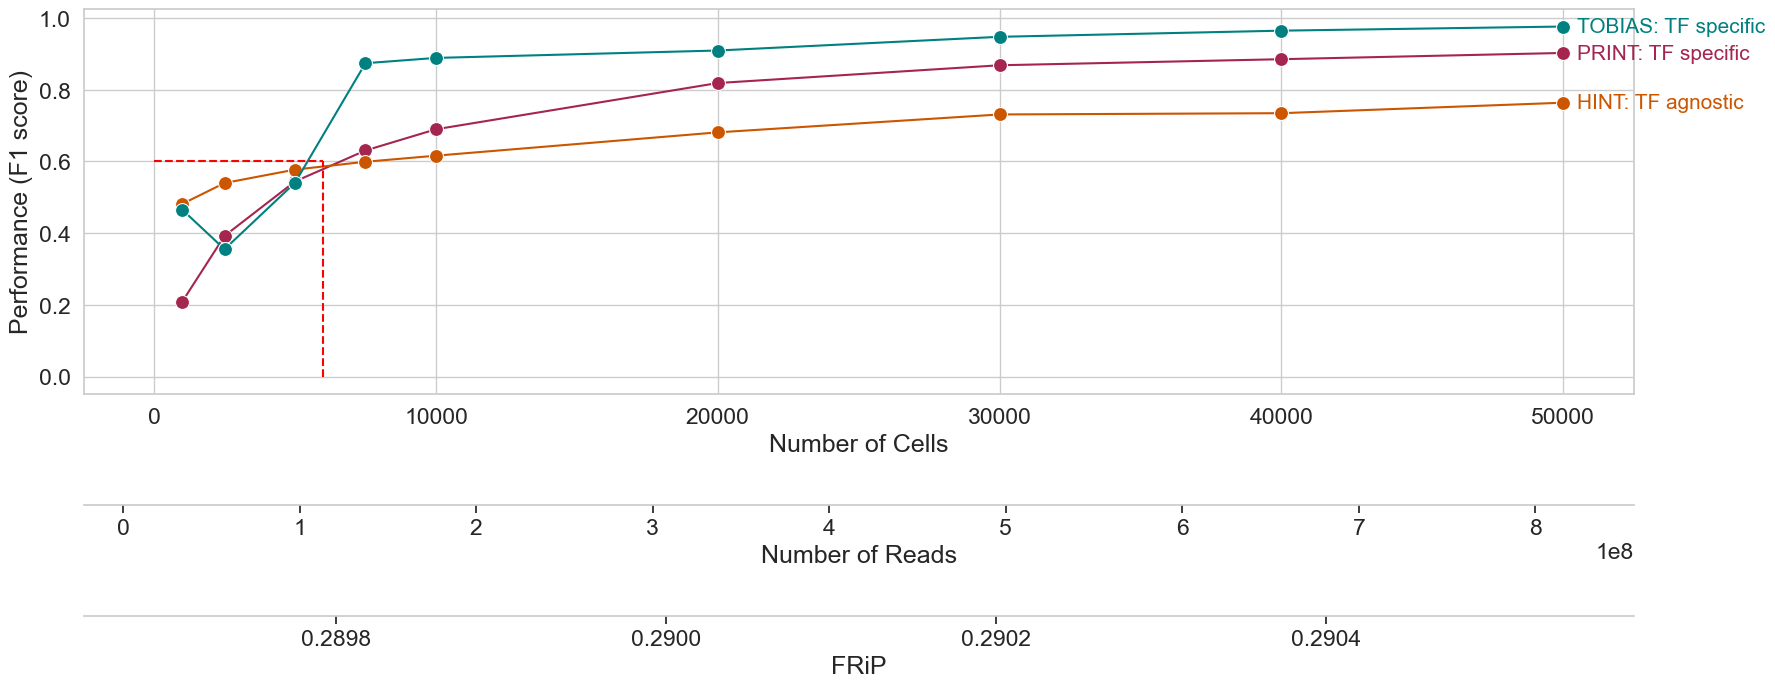

In [23]:
from scipy.interpolate import interp1d

def quick_gather(cl, tool, by="tf"):
    if tool == "hint":
        data_dir = f"../06_dataquality/{tool}/metrics/no_threshold/"
    elif tool == "tobias":
        data_dir = f"../06_dataquality/{tool}/metrics/bound_threshold/"
    elif tool == "print":
        data_dir = f"../06_dataquality/{tool}/metrics/thresh_03/"

    df = pd.DataFrame()
    tmp = pd.read_csv(f"{data_dir}/{cl}_by{by}.csv.gz", sep=",", index_col=0)
    cond1 = tmp["by"] == "file" 
    cond3 = tmp["sampling_type"] == "baseline"
    df = pd.concat([df, tmp[cond1 | cond3].copy()]) 
    df = df[df.sampling_type != "peakreads"]
    df["cell_line"] = cl
    df["tool"] = tool
    return df
    

fig = plt.figure(figsize=(20, 5))
gs = GridSpec(1,1, figure=fig)

ax1 = fig.add_subplot(gs[0]) 

df = pd.concat([quick_gather("HEPG2", "print", by="tf"),
                quick_gather("K562", "print", by="tf"),
                quick_gather("MCF7", "print", by="tf"),
                quick_gather("SKNSH", "print", by="tf"),
                
                quick_gather("HEPG2", "hint", by="peak"),
                quick_gather("K562", "hint", by="peak"),
                quick_gather("MCF7", "hint", by="peak"),
                quick_gather("SKNSH", "hint", by="peak"),

                # quick_gather("HEPG2", "hint",  by="tf"),
                # quick_gather("K562", "hint",  by="tf"),
                # quick_gather("MCF7", "hint", by="tf"),
                # quick_gather("SKNSH", "hint", by="tf"),
                
                 quick_gather("HEPG2", "tobias", by="tf"),
                quick_gather("K562",  "tobias", by="tf"),
                quick_gather("MCF7",  "tobias", by="tf"),
                quick_gather("SKNSH",  "tobias", by="tf"),
               ])
df = df[df.sampling_type == "cells"]


x1 = "Ncells"
x2 = "Nreadpairs"
x3 = "FRIP"
y = "f1"

sns.lineplot(data = df, x=x1, y=f"{y}_mean", hue="tool", 
             markersize=10, marker="o", errorbar=None,
              ax=ax1, palette = color_scheme_prog)
ax1.set_xlabel("Number of Cells")
ax1.set_ylabel("Performance (F1 score)")

for tool, subdf in df.groupby("tool"):
    subdf_sorted = subdf.sort_values(by=x1)
    x_last = subdf_sorted[x1].iloc[-1]
    y_last = subdf_sorted[f"{y}_mean"].iloc[-1]

    if tool in ["tobias", "print"]:
        label = f"{tool.upper()}: TF specific"
    elif tool == "hint":
        label = f"{tool.upper()}: TF agnostic"
        
    ax1.text(
        x_last + 0.01 * (df[x1].max() - df[x1].min()), 
        y_last,
        label,
        color=color_scheme_prog[tool],
        va='center',
        fontsize=15
    )

ax1.legend_.remove()


ax1.plot([0, 6000], [0.6, 0.6], ls='--', color='red')
ax1.plot([6000, 6000], [0, 0.6], ls='--', color='red')

coeffs = np.polyfit(df[x1].values, df[x2].values, deg=1)
x1_to_x2 = np.poly1d(coeffs)
coeffs = np.polyfit(df[x2].values, df[x1].values, deg=1)
x2_to_x1 = np.poly1d(coeffs)
ax2 = ax1.secondary_xaxis('bottom', functions=(x1_to_x2, x2_to_x1))
ax2.spines['bottom'].set_position(('outward', 80))  # Push it down
ax2.set_xlabel('Number of Reads')
ax2.tick_params(axis='x')


coeffs = np.polyfit(df[x1].values, df[x3].values, deg=1)
x1_to_x2 = np.poly1d(coeffs)
coeffs = np.polyfit(df[x3].values, df[x1].values, deg=1)
x2_to_x1 = np.poly1d(coeffs)
ax3 = ax1.secondary_xaxis('bottom', functions=(x1_to_x2, x2_to_x1))
ax3.spines['bottom'].set_position(('outward', 160))  # Push it down
ax3.set_xlabel('FRiP')
ax3.tick_params(axis='x')

plt.show()

# 3. Plot replicate similarity <a class="anchor" id="third-bullet"></a>

In [25]:
def transform_to_dict(file_list):
    result = {}
    for item in file_list:
        key = "_".join(item.split("_")[:-1])
        result.setdefault(key, []).append(item)
    return result


all_corrs = []
analysis_type="tf"
for prog in ["hint", "tobias", "print"]:
    for cl in ["K562", "MCF7", "SKNSH", "HEPG2"]:
        print(prog, cl)
       
        if tool == "hint":
            data_dir = f"../../06_dataquality/{tool}/metrics/no_threshold/"
        elif tool == "tobias":
            data_dir = f"../../06_dataquality/{tool}/metrics/bound_threshold/"
        elif tool == "print":
            data_dir = f"../../06_dataquality/{tool}/metrics/thresh_03/"
 
        files1 = [x for x in os.listdir(data_dir) if x.endswith("_metrics.csv") and cl in x]
        files = [x for x in files1 if "_p" not in x ]
        files.remove(f"{cl}_metrics.csv")

        p_dict = {
            re.sub(f"{cl}_|_metrics.csv", "", f): pd.read_csv(
                os.path.join(data_dir, f), index_col=0
            )
            .query("type == @analysis_type")
            .sort_index()["f1"]
            for f in files
        }

        tf_df = pd.DataFrame.from_dict(p_dict)
        grouping_dict = transform_to_dict(tf_df.columns)
        for g in grouping_dict:
            all_corrs.extend(tf_df[grouping_dict[g]].corr().values[0][1:3])
print("done")
print(f"Given all triplicate correlations (length:{len(all_corrs)}), the mean is {np.mean(all_corrs)} and sd {np.std(all_corrs)}")

hint K562
hint MCF7
hint SKNSH
hint HEPG2
tobias K562
tobias MCF7
tobias SKNSH
tobias HEPG2
print K562
print MCF7
print SKNSH
print HEPG2
done
Given all triplicate correlations (length:516), the mean is 0.9906031218384436 and sd 0.021161989235093312


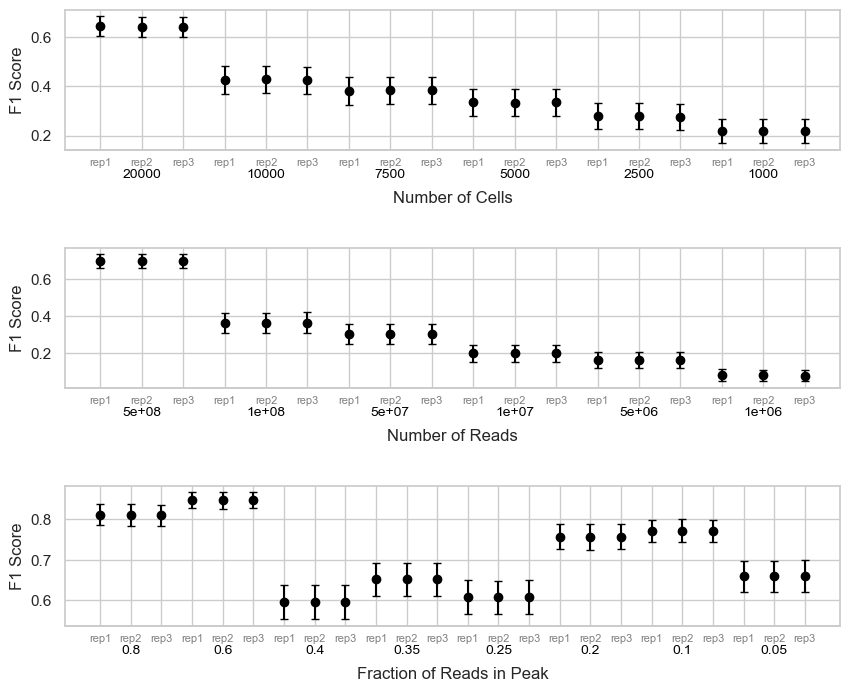

In [26]:
def _arbitrarily_hard_formatting(ax, df, group):
    tmp = df[df.group == group].copy()
    tmp["xaxis"]= tmp["xaxis"].astype(float) 
    tmp = tmp.sort_values(by='xaxis', ascending=False)
    xaxis_primary = ["rep1", "rep2", "rep3"] * len(np.unique(tmp["value"]))
    
    if group == "c":
        xaxis_secondary = ["\n{:.0f}".format(i) for i in np.unique(tmp["value"])][::-1]
    elif group == "r":
        xaxis_secondary = ["\n{:.0e}".format(i) for i in np.unique(tmp["value"])][::-1]
    else:  
        xaxis_secondary = [f"\n{i}" for i in np.unique(tmp["value"])][::-1]

    ax.errorbar(tmp["index"], tmp["f1_mean"], yerr=tmp["f1_sd"], fmt='o', capsize=3, color="black")
    #ax.set_ylim(0, 1)
    ax.set_ylabel("F1 Score")
    
    #primary xaxis
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(xaxis_primary, size=8, color="grey")
    ax.tick_params(axis='x', pad=0) #make it closer to tick line

    #secondary axis
    xaxis_secondary_location =  []
    for a,b in zip(["rep1", "rep2", "rep3"] * len(np.unique(tmp["value"])), ax.get_xticks()):
        if a == "rep2": xaxis_secondary_location.append(b)
    sec = ax.secondary_xaxis(location=0)
    sec.set_xticks(xaxis_secondary_location, labels=xaxis_secondary, size=10, color="black")
    sec.tick_params('x', length=0)

    return ax

tool = "hint"
data_dir = f"../06_dataquality/{tool}/metrics/no_threshold/"
cl = "HEPG2"
df = pd.read_csv(f"{data_dir}/{cl}_bytf.csv.gz", sep=",", index_col=0)
df = df[(df["by"] == "file") & (df.sampling_type != "baseline")]

df.reset_index(inplace=True)
df["xaxis"] = df["index"].str.split("_", expand=True)[1]
df["group"] = df['xaxis'].apply(lambda x: x[0])
df['xaxis'] = df['xaxis'].apply(lambda x: x[1:])



sns.set(style='whitegrid')
fig = plt.figure(figsize=(10,8))
gs = GridSpec(3,1, figure=fig, hspace=0.7)

ax = fig.add_subplot(gs[0])
ax = _arbitrarily_hard_formatting(ax, df, "c")
ax.set_xlabel("\nNumber of Cells")

ax = fig.add_subplot(gs[1])
ax = _arbitrarily_hard_formatting(ax, df, "r")
ax.set_xlabel("\nNumber of Reads")

ax = fig.add_subplot(gs[2])
ax = _arbitrarily_hard_formatting(ax, df, "f")
ax.set_xlabel("\nFraction of Reads in Peak")
plt.show()

In [31]:
prog="hint"
analysis_type="tf"

if tool == "hint":
    data_dir = f"../../06_dataquality/{tool}/metrics/no_threshold/"
elif tool == "tobias":
    data_dir = f"../../06_dataquality/{tool}/metrics/bound_threshold/"
elif tool == "print":
    data_dir = f"../../06_dataquality/{tool}/metrics/thresh_03/"

 
prefix = "K562_c"
files = [x for x in os.listdir(data_dir) if x.endswith("_metrics.csv") and prefix in x]

p_dict = {}
for f in files:
    df = pd.read_csv(f"{data_dir}/{f}", index_col=0)
    df = df.loc[df["type"] == analysis_type]
    df = df.sort_index(ascending=True)
    p_dict[re.sub(f"{prefix}|_metrics.csv", '', f) ] = df["f1"]

p_dict["TF"] = df.index
tf_df = pd.DataFrame.from_dict(p_dict)

#rename columns to rep1 and so on. via ChatGPT
df = pd.DataFrame(tf_df.columns, columns=['value'])
df['prefix'] = df['value'].str.split('_').str[0]
df['rep'] = df.groupby('prefix').cumcount() + 1
df['rep'] = "_rep" + df['rep'].astype(str)
df.loc[df.value=="TF", "rep"] = ""
df['new_value'] = df['prefix'] + df['rep'] 
result = df['new_value'].tolist()
tf_df.columns = result

melted_df = tf_df.melt(id_vars=['TF'], 
                       var_name='File', 
                       value_name='F1')


melted_df[["value", "rep"]] = melted_df.File.str.split('_', expand=True)
melted_df["value"] = melted_df["value"].astype(float)
melted_df = melted_df.sort_values(by=['value', "rep"], ascending=[False, True])
display(melted_df)

,TF,File,F1,value,rep
6728,AHR::ARNT_MA0006.1,40000_rep1,0.726287,40000.0,rep1
6729,ALX1_MA0854.1,40000_rep1,0.594095,40000.0,rep1
6730,ALX3_MA0634.1,40000_rep1,0.662186,40000.0,rep1
6731,ALX4_MA0853.1,40000_rep1,0.592638,40000.0,rep1
6732,ARGFX_MA1463.1,40000_rep1,0.653009,40000.0,rep1
...,...,...,...,...,...
20179,ZNF8_MA1718.1,1000_rep3,0.121327,1000.0,rep3
20180,ZNF93_MA1721.1,1000_rep3,0.228589,1000.0,rep3
20181,ZSCAN29_MA1602.1,1000_rep3,0.183713,1000.0,rep3
20182,ZSCAN31_MA1722.1,1000_rep3,0.133247,1000.0,rep3


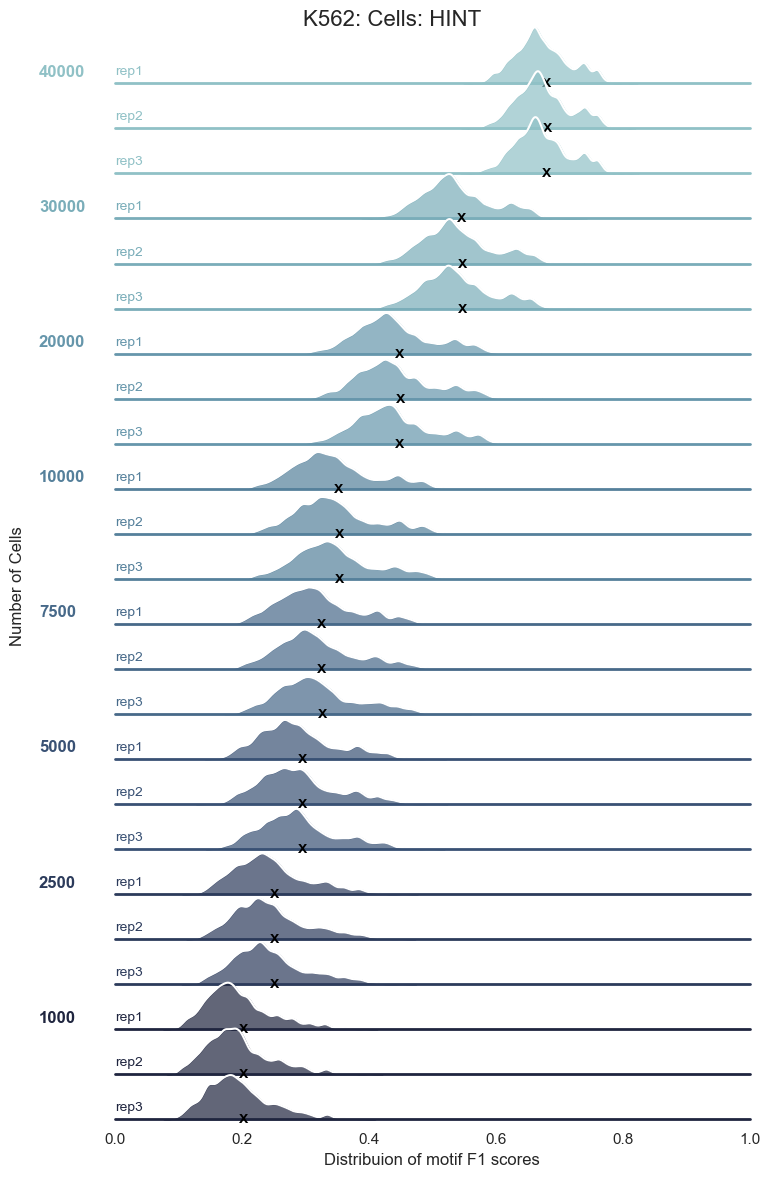

In [32]:
color="blue"

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

ncol = len(np.unique(melted_df.value))
if color == "blue": pal = sns.cubehelix_palette(ncol, rot=-.25, light=.7)
elif color == "green": pal = sns.cubehelix_palette(ncol, rot=-.15, light=.7, start=8)
elif color == "purple": pal = sns.cubehelix_palette(ncol, rot=.25, light=.7)
else: print("color not recognized: options are blue, green, purple")               
repeated_palette = [i for i in pal for _ in range(3)]

g = sns.FacetGrid(melted_df, row="File", hue="File",  palette=repeated_palette, aspect=15, height=0.5) #aspect=5, height=0.5,
g.map(sns.kdeplot, "F1", bw_adjust=.5, clip_on=False, fill=True, alpha=0.7, linewidth=1)
g.map(sns.kdeplot, "F1", clip_on=False, color="w", lw=1.5, bw_adjust=.5)
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    
    #get just the rep number and make that smaller. 
    rep_label = label.split("_")[1]
    ax.text(0, .2, rep_label, size=10, color=color, ha="left", va="center", transform=ax.transAxes)
    
    #add the condition a little larger. 
    if rep_label == "rep1":
        ax.text(-0.12, .2, label.split("_")[0], size=12, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)
    
    #add red line
    x_mean = melted_df[melted_df.File == label].F1.mean()
    ax.text(x_mean, 0, "X", size=10, fontweight="bold", color="black", ha="left", va="center", transform=ax.transAxes)
    return

g.map(label, "F1")

g.set(xlim=(0,1))
g.figure.subplots_adjust(hspace=-.25)
g.set_titles("")
g.set(yticks=[], ylabel="", xlabel="")
g.despine(bottom=True, left=True)

last_ax = g.axes.flat[-1]  # Last axis in the grid
last_ax.set_xlabel("Distribuion of motif F1 scores", fontsize=12)

plt.suptitle("K562: Cells: HINT", fontsize=16)

plt.figtext(0, 0.5, "Number of Cells", ha="center", va="center", rotation="vertical", fontsize=12)

plt.show()